/var/folders/_r/g5v5d0h10js35qrtd7p03v_40000gn/T/ipykernel_93214/2739774895.py:53: LinAlgWarning: Ill-conditioned matrix (rcond=1.0688e-16): result may not be accurate.
  Wout = linalg.solve(


MSE: 7.7679e+03


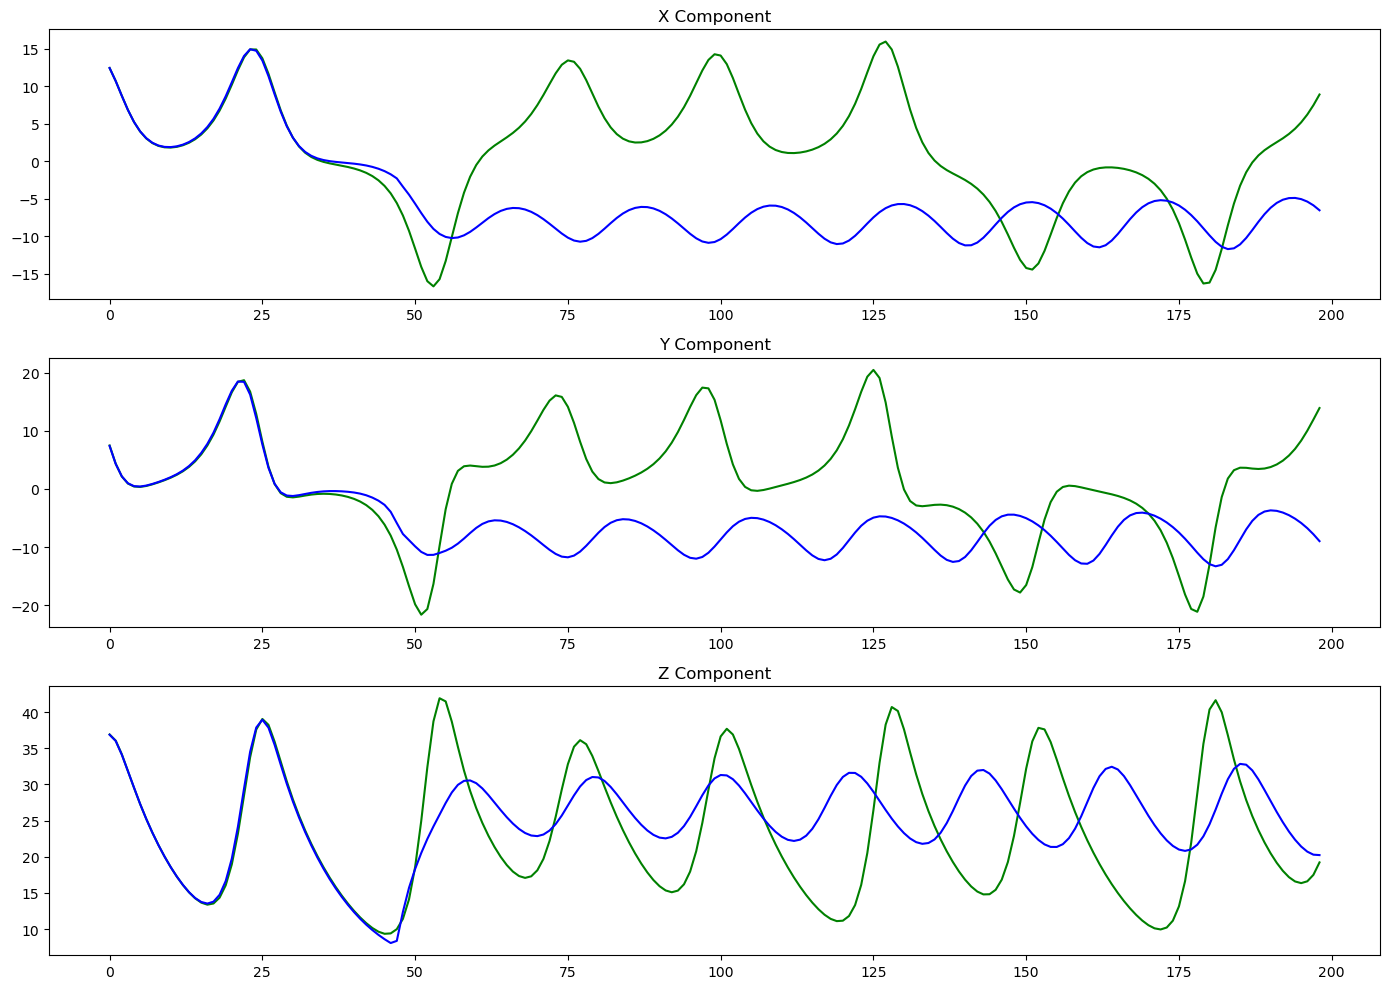

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from reservoirpy.datasets import lorenz  # Changed import

# Parameters (adjusted for Lorenz)
input_size = 3  # x, y, z dimensions
output_size = 3
res_size = 800  # Larger reservoir for complex dynamics
spectral_radius = 1.25
leak_rate = 0.3
input_scaling = 0.5
J = 1.0
train_len = 1500
test_len = 2000

# Data loading function
def load_data(train_len=train_len, test_len=test_len):
    total_len = train_len + test_len + 100
    data = lorenz(n_timesteps=total_len, seed=42)
    return data, train_len, test_len

# Reservoir creation (no changes needed except input_size)
def gaussian_reservoir(input_size=input_size, res_size=res_size, J=J, seed=45):
    np.random.seed(seed)
    Win = 2 * (np.random.rand(res_size, 1 + input_size) - 0.5)
    W = np.random.normal(0, J/np.sqrt(res_size), (res_size, res_size))
    np.fill_diagonal(W, 0)
    return Win, W

def initialize_reservoir(input_size=input_size, res_size=res_size, 
                        spectral_radius=spectral_radius, seed=45, J=J):
    Win, W = gaussian_reservoir(input_size=input_size, res_size=res_size, J=J, seed=seed)
    rhoW = max(abs(linalg.eig(W)[0]))
    W *= spectral_radius / rhoW
    return Win, W

def run_reservoir(data, Win, W, train_len, init_len, leak_rate, res_size):
    X = np.zeros((1 + input_size + res_size, train_len - init_len))
    Yt = data[init_len+1:train_len+1].T  # Transposed for correct shape
    x = np.zeros((res_size, 1))
    
    for t in range(train_len):
        u = data[t]
        x = (1-leak_rate)*x + leak_rate*np.tanh(
            np.dot(Win, np.vstack((1, u.reshape(-1,1)))) + np.dot(W, x))
        if t >= init_len:
            X[:, t-init_len] = np.vstack((1, u.reshape(-1,1), x))[:,0]
            
    return X, Yt, x

def train_output_weights(X, Yt, reg=1e-8):
    Wout = linalg.solve(
        np.dot(X, X.T) + reg*np.eye(X.shape[0]),
        np.dot(X, Yt.T)
    ).T
    return Wout

def run_generative_mode(data, Win, W, Wout, x, train_len, test_len, leak_rate):
    Y = np.zeros((output_size, test_len))
    u = data[train_len]
    
    for t in range(test_len):
        x = (1-leak_rate)*x + leak_rate*np.tanh(
            np.dot(Win, np.vstack((1, u.reshape(-1,1)))) + np.dot(W, x))
        y = np.dot(Wout, np.vstack((1, u.reshape(-1,1), x)))
        Y[:, t] = y.flatten()
        u = y  # Generative mode
    return Y

def compute_mse(data, Y, train_len, error_len=500):
    target = data[train_len+1:train_len+error_len+1].T
    prediction = Y[:, :error_len]
    return np.mean((target - prediction)**2)

# Modified plotting function
def plot_results(data, Y, train_len):
    plt.figure(figsize=(14,10))
    
    # Plot X component
    plt.subplot(3,1,1)
    plt.plot(data[train_len+1:train_len+200, 0], 'g')
    plt.plot(Y[0,:199].T, 'b')
    plt.title('X Component')
    
    # Plot Y component
    plt.subplot(3,1,2)
    plt.plot(data[train_len+1:train_len+200, 1], 'g')
    plt.plot(Y[1,:199].T, 'b')
    plt.title('Y Component')
    
    # Plot Z component
    plt.subplot(3,1,3)
    plt.plot(data[train_len+1:train_len+200, 2], 'g')
    plt.plot(Y[2,:199].T, 'b')
    plt.title('Z Component')
    
    plt.tight_layout()

# Main execution
data, trainLen, testLen = load_data()
Win, W = initialize_reservoir(input_size=input_size, res_size=res_size)
X, Yt, x = run_reservoir(data, Win, W, trainLen, init_len=100, 
                        leak_rate=leak_rate, res_size=res_size)
Wout = train_output_weights(X, Yt)
Y = run_generative_mode(data, Win, W, Wout, x, trainLen, testLen, leak_rate)

mse = compute_mse(data, Y, trainLen)
print(f'MSE: {mse:.4e}')

plot_results(data, Y, trainLen)
plt.show()


ValueError: too many values to unpack (expected 3)